# Online Shoppers Purchasing Intention — Preprocessing, Perbandingan Model & Decision Tree (Optuna Tuning)

Notebook tunggal (satu file, end-to-end) untuk memprediksi purchase intention (`Revenue`) pada **Online Shoppers Purchasing Intention Dataset** dari UCI Machine Learning Repository.

- **Sumber dataset:** https://archive.ics.uci.edu/dataset/468/online%20shoppers%20purchasing%20intention%20dataset
- **Kaggle Dataset (mirror publik):** https://www.kaggle.com/datasets/dimaspashaakrilian/online-shoppers-purchasing-intention-dataset

**Alur notebook:**
1. Eksplorasi Data (EDA) & Cleaning
2. Feature Engineering & Encoding
3. Train-Test Split
4. **Perbandingan 7 model klasifikasi murah** (Logistic Regression, Decision Tree, Naive Bayes, KNN, Random Forest, XGBoost, LightGBM) — cost (waktu) vs performa
5. **Kenapa Decision Tree dipilih sebagai model final** (alasan berdasarkan data di langkah 4)
6. Hyperparameter Tuning Decision Tree dengan **Optuna** (objective: PR-AUC 5-fold CV)
7. **Precision-Recall Curve & Threshold Optimization** (out-of-fold, tanpa leakage ke test set)
8. Evaluasi Final & Simpan Model

Dijalankan sepenuhnya di **CPU** (accelerator: None, bukan GPU T4).

In [1]:
import os
import glob
import time
import math
import json as _json

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_score, cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

try:
    import optuna
except ImportError:
    import sys as _sys
    get_ipython().system(f'{_sys.executable} -m pip install -q optuna')
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("optuna version:", optuna.__version__)


optuna version: 4.9.0


/tmp/claude-1000/-home-pasha-akrilian-Documents-Kuliah/2a19719e-8ed7-486e-a1dc-a02c61afee26/scratchpad/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Memuat Data

Mencoba beberapa lokasi umum: input Kaggle Dataset, lalu fallback ke file lokal.

In [2]:
FILENAME = "online_shoppers_intention.csv"

candidate_paths = [
    f"/kaggle/input/online-shoppers-purchasing-intention-dataset/{FILENAME}",
    f"../input/online-shoppers-purchasing-intention-dataset/{FILENAME}",
    FILENAME,
    f"../online+shoppers+purchasing+intention+dataset/{FILENAME}",
]

data_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if data_path is None:
    matches = glob.glob(f"/kaggle/input/**/{FILENAME}", recursive=True)
    if matches:
        data_path = matches[0]

if data_path is None:
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Pastikan Kaggle Dataset "
        "'dimaspashaakrilian/online-shoppers-purchasing-intention-dataset' sudah ditambahkan "
        "sebagai data source pada notebook ini (Add Data)."
    )

print("Membaca dataset dari:", data_path)
df = pd.read_csv(data_path)
df.shape


Membaca dataset dari: online_shoppers_intention.csv


(12330, 18)

## 1. Eksplorasi Data Awal (EDA)

In [3]:
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [5]:
missing = df.isnull().sum()
missing[missing > 0] if missing.sum() > 0 else print("Tidak ada missing value pada dataset ini.")


Tidak ada missing value pada dataset ini.


In [6]:
n_dupes = df.duplicated().sum()
print(f"Jumlah baris duplikat: {n_dupes} dari {len(df)} baris ({n_dupes/len(df):.2%})")


Jumlah baris duplikat: 125 dari 12330 baris (1.01%)


In [7]:
target_dist = df["Revenue"].value_counts(normalize=True).rename("proportion").to_frame()
target_dist["count"] = df["Revenue"].value_counts()
target_dist


,proportion,count
Revenue,,
False,0.845255,10422
True,0.154745,1908


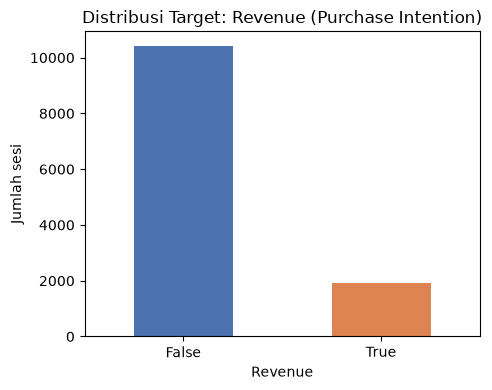

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
df["Revenue"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Distribusi Target: Revenue (Purchase Intention)")
ax.set_xlabel("Revenue")
ax.set_ylabel("Jumlah sesi")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Catatan EDA:**
- 12.330 baris sesi kunjungan e-commerce, 17 fitur + 1 target (`Revenue`), tidak ada missing value.
- Terdapat baris duplikat yang akan dibuang.
- Target imbalanced (~85% False / ~15% True) → accuracy saja tidak cukup, evaluasi fokus ke PR-AUC/F1/threshold optimization.
- Fitur kategorikal nominal: `Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`.

## 2. Data Cleaning

In [9]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Baris sebelum: {before}, sesudah drop_duplicates: {after}, dibuang: {before - after}")


Baris sebelum: 12330, sesudah drop_duplicates: 12205, dibuang: 125


## 3. Feature Engineering & Encoding

1. `Weekend`/`Revenue` → 0/1.
2. One-hot encoding untuk fitur kategorikal nominal.
3. Fitur numerik dibiarkan apa adanya — scaling dilakukan di dalam `Pipeline` (fit hanya pada data train), menghindari data leakage.

In [10]:
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

categorical_nominal = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
df_encoded = pd.get_dummies(df, columns=categorical_nominal, drop_first=True)

bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape sebelum encoding:", df.shape)
print("Shape sesudah encoding:", df_encoded.shape)
df_encoded.head()


Shape sebelum encoding: (12205, 18)
Shape sesudah encoding: (12205, 69)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8,Browser_2,Browser_3,Browser_4,Browser_5,Browser_6,Browser_7,Browser_8,Browser_9,Browser_10,Browser_11,Browser_12,Browser_13,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9,TrafficType_2,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,TrafficType_10,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4. Train-Test Split

Split stratified 80/20 berdasarkan target `Revenue`.

In [11]:
X = df_encoded.drop(columns=["Revenue"])
y = df_encoded["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("\nProporsi target - train:")
print(y_train.value_counts(normalize=True))
print("\nProporsi target - test:")
print(y_test.value_counts(normalize=True))


X_train: (9764, 68) | X_test: (2441, 68)

Proporsi target - train:
Revenue
0    0.843712
1    0.156288
Name: proportion, dtype: float64

Proporsi target - test:
Revenue
0    0.843507
1    0.156493
Name: proportion, dtype: float64


## 5. Perbandingan 7 Model Klasifikasi Murah (CPU only)

Sebelum memutuskan model final, 7 model klasik yang murah secara komputasi dibandingkan dulu (parameter default), semua dijalankan di **CPU**:

1. **Logistic Regression**
2. **Decision Tree**
3. **Gaussian Naive Bayes**
4. **K-Nearest Neighbors (KNN)**
5. **Random Forest**
6. **XGBoost** (`tree_method="hist"`, CPU)
7. **LightGBM** (histogram-based, CPU)

Perbandingan dari dua sisi:
- **Cost**: `fit_time` & `score_time` (5-fold CV) + waktu training/prediksi penuh di holdout test.
- **Performa**: accuracy, precision, recall, F1, ROC-AUC (target imbalanced, accuracy saja tidak cukup).

In [12]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Naive Bayes (Gaussian)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB()),
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=15, n_jobs=1)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=100, max_depth=10, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=1,
        )),
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            tree_method="hist", device="cpu", eval_metric="logloss",
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=1,
        )),
    ]),
    "LightGBM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LGBMClassifier(
            n_estimators=100, max_depth=-1, learning_rate=0.1,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1, verbose=-1,
        )),
    ]),
}

list(models.keys())


['Logistic Regression',
 'Decision Tree',
 'Naive Bayes (Gaussian)',
 'K-Nearest Neighbors',
 'Random Forest',
 'XGBoost',
 'LightGBM']

### 5.1 Cross-Validation: Cost (waktu) & Performa

In [13]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_rows = []

for name, pipe in models.items():
    print(f"Menjalankan 5-fold CV untuk: {name} ...")
    result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1, return_train_score=False)
    cv_rows.append({
        "model": name,
        "fit_time_sec_mean": result["fit_time"].mean(),
        "score_time_sec_mean": result["score_time"].mean(),
        "accuracy_mean": result["test_accuracy"].mean(),
        "precision_mean": result["test_precision"].mean(),
        "recall_mean": result["test_recall"].mean(),
        "f1_mean": result["test_f1"].mean(),
        "roc_auc_mean": result["test_roc_auc"].mean(),
    })

cv_summary = pd.DataFrame(cv_rows).sort_values("fit_time_sec_mean").reset_index(drop=True)
cv_summary


Menjalankan 5-fold CV untuk: Logistic Regression ...


Menjalankan 5-fold CV untuk: Decision Tree ...


Menjalankan 5-fold CV untuk: Naive Bayes (Gaussian) ...


Menjalankan 5-fold CV untuk: K-Nearest Neighbors ...


Menjalankan 5-fold CV untuk: Random Forest ...


Menjalankan 5-fold CV untuk: XGBoost ...


Menjalankan 5-fold CV untuk: LightGBM ...


,model,fit_time_sec_mean,score_time_sec_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,K-Nearest Neighbors,0.026746,0.288490,0.854364,0.699528,0.118605,0.202792,0.755921
1,Naive Bayes (Gaussian),0.026764,0.024115,0.249489,0.170738,0.985587,0.291051,0.586465
2,Decision Tree,0.066019,0.021616,0.843711,0.499995,0.739839,0.596542,0.834170
3,XGBoost,0.200222,0.028667,0.863888,0.542799,0.821099,0.653417,0.929610
4,LightGBM,0.210625,0.044155,0.879865,0.588127,0.777188,0.669253,0.927189
5,Logistic Regression,0.316916,0.048576,0.845146,0.503368,0.751653,0.602843,0.896185
6,Random Forest,0.745627,0.069287,0.865015,0.545432,0.823720,0.656023,0.923454


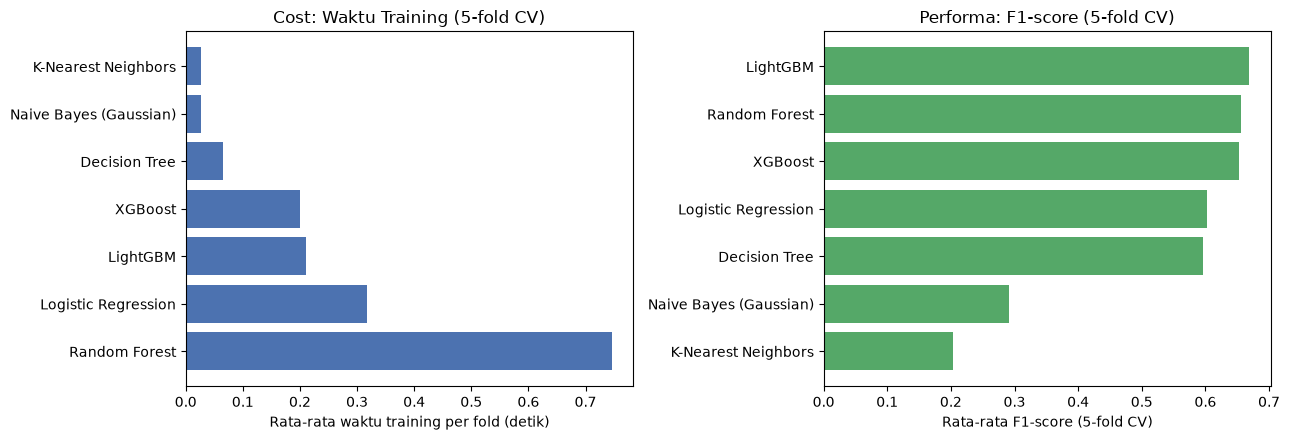

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = cv_summary.sort_values("fit_time_sec_mean")
axes[0].barh(order["model"], order["fit_time_sec_mean"], color="#4C72B0")
axes[0].set_xlabel("Rata-rata waktu training per fold (detik)")
axes[0].set_title("Cost: Waktu Training (5-fold CV)")
axes[0].invert_yaxis()

order2 = cv_summary.sort_values("f1_mean", ascending=False)
axes[1].barh(order2["model"], order2["f1_mean"], color="#55A868")
axes[1].set_xlabel("Rata-rata F1-score (5-fold CV)")
axes[1].set_title("Performa: F1-score (5-fold CV)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


### 5.2 Evaluasi di Test Set (Holdout)

In [15]:
test_rows = []
fitted_models = {}
roc_data = {}

for name, pipe in models.items():
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = pipe.predict(X_test)
    predict_time = time.perf_counter() - t0

    y_proba = pipe.predict_proba(X_test)[:, 1]

    fitted_models[name] = pipe
    roc_data[name] = roc_curve(y_test, y_proba)

    test_rows.append({
        "model": name,
        "fit_time_full_train_sec": fit_time,
        "predict_time_test_sec": predict_time,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

test_summary = pd.DataFrame(test_rows).sort_values("f1", ascending=False).reset_index(drop=True)
test_summary


,model,fit_time_full_train_sec,predict_time_test_sec,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.820854,0.028371,0.868497,0.553043,0.832461,0.664577,0.926644
1,LightGBM,0.244309,0.017689,0.873003,0.566667,0.801047,0.663774,0.930886
2,XGBoost,0.231114,0.007259,0.863990,0.541667,0.850785,0.661914,0.936949
3,Logistic Regression,0.401783,0.004168,0.846374,0.505824,0.795812,0.618515,0.908338
4,Decision Tree,0.105772,0.005225,0.853339,0.522305,0.735602,0.610870,0.825798
5,Naive Bayes (Gaussian),0.036630,0.007260,0.244982,0.169307,0.979058,0.288692,0.581294
6,K-Nearest Neighbors,0.029413,0.246213,0.854158,0.685714,0.125654,0.212389,0.744860


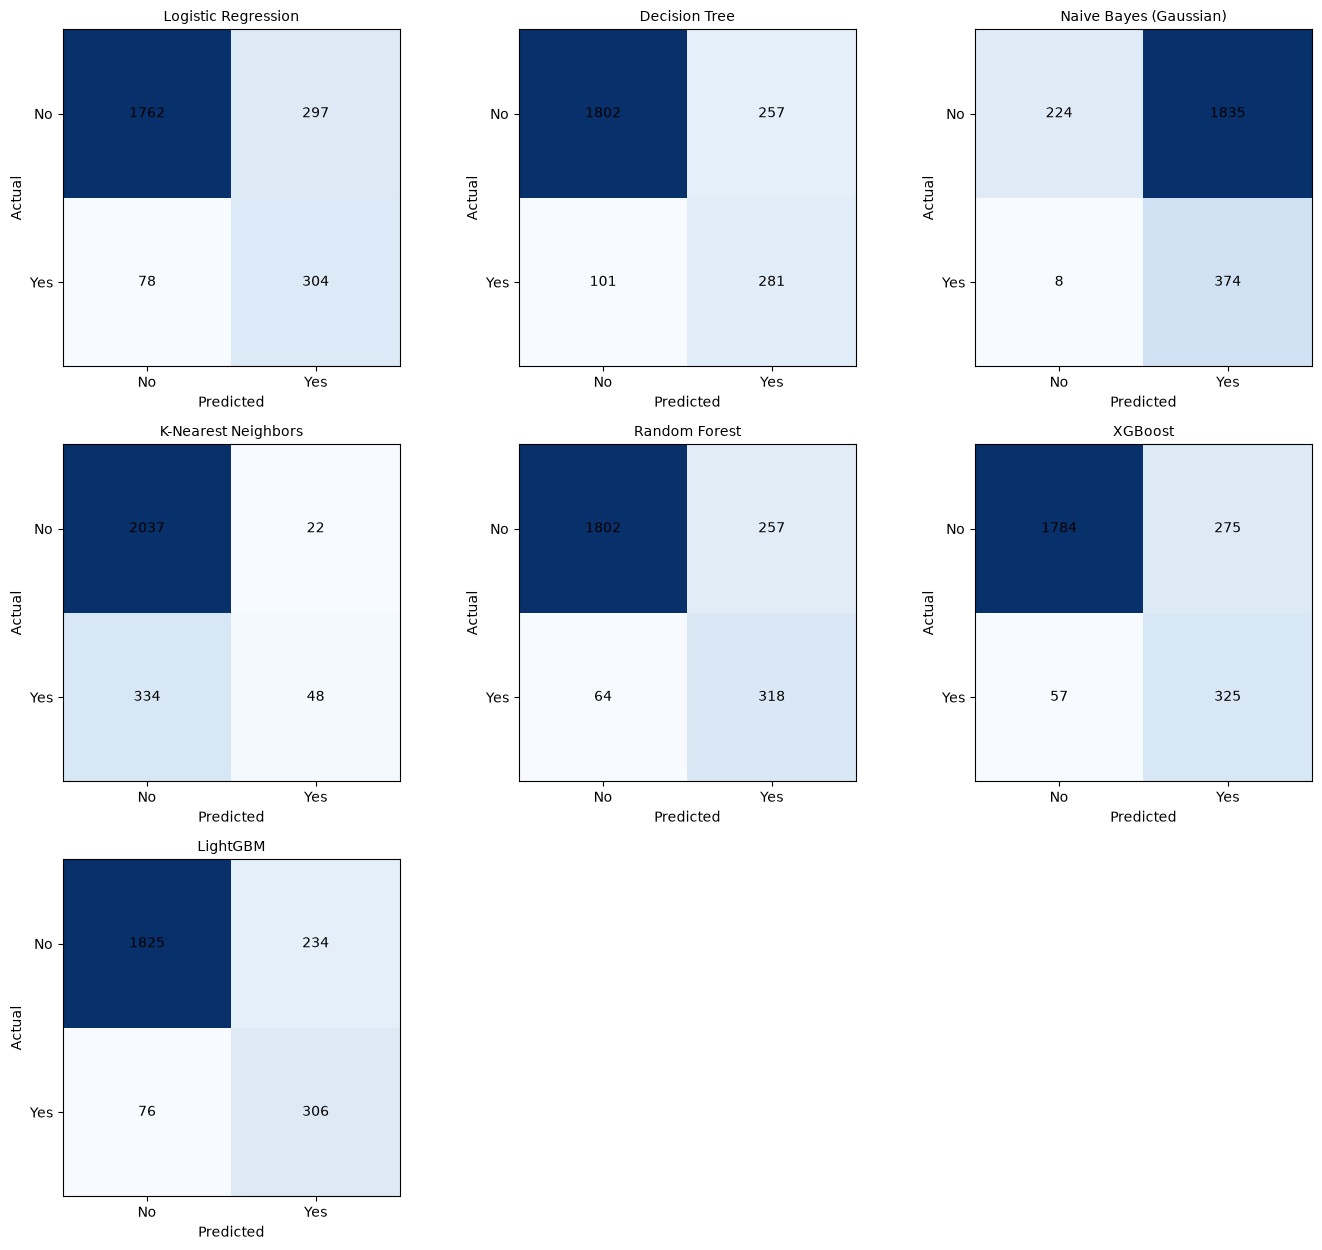

In [16]:
ncols = 3
nrows = math.ceil(len(fitted_models) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
axes = axes.ravel()

for i, (name, pipe) in enumerate(fitted_models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ax = axes[i]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No", "Yes"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["No", "Yes"])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha="center", va="center", color="black")

for j in range(len(fitted_models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


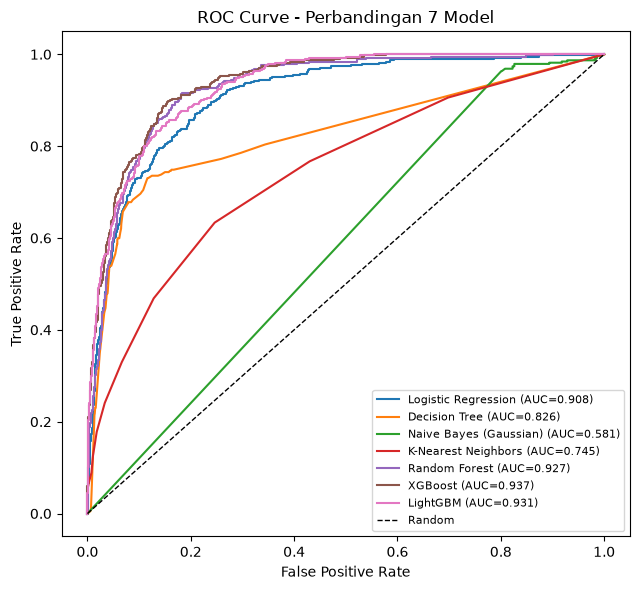

In [17]:
plt.figure(figsize=(6.5, 6))
for name, (fpr, tpr, _) in roc_data.items():
    auc = test_summary.loc[test_summary["model"] == name, "roc_auc"].values[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Perbandingan 7 Model")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


### 5.3 Ringkasan Cost vs Performa

In [18]:
test_summary_renamed = test_summary[[
    "model", "fit_time_full_train_sec", "predict_time_test_sec", "accuracy", "f1", "roc_auc"
]].rename(columns={"accuracy": "accuracy_test", "f1": "f1_test", "roc_auc": "roc_auc_test"})

summary = cv_summary.merge(test_summary_renamed, on="model").sort_values("fit_time_sec_mean").reset_index(drop=True)
summary


,model,fit_time_sec_mean,score_time_sec_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,fit_time_full_train_sec,predict_time_test_sec,accuracy_test,f1_test,roc_auc_test
0,K-Nearest Neighbors,0.026746,0.288490,0.854364,0.699528,0.118605,0.202792,0.755921,0.029413,0.246213,0.854158,0.212389,0.744860
1,Naive Bayes (Gaussian),0.026764,0.024115,0.249489,0.170738,0.985587,0.291051,0.586465,0.036630,0.007260,0.244982,0.288692,0.581294
2,Decision Tree,0.066019,0.021616,0.843711,0.499995,0.739839,0.596542,0.834170,0.105772,0.005225,0.853339,0.610870,0.825798
3,XGBoost,0.200222,0.028667,0.863888,0.542799,0.821099,0.653417,0.929610,0.231114,0.007259,0.863990,0.661914,0.936949
4,LightGBM,0.210625,0.044155,0.879865,0.588127,0.777188,0.669253,0.927189,0.244309,0.017689,0.873003,0.663774,0.930886
5,Logistic Regression,0.316916,0.048576,0.845146,0.503368,0.751653,0.602843,0.896185,0.401783,0.004168,0.846374,0.618515,0.908338
6,Random Forest,0.745627,0.069287,0.865015,0.545432,0.823720,0.656023,0.923454,0.820854,0.028371,0.868497,0.664577,0.926644


In [19]:
cheapest = summary.sort_values("fit_time_sec_mean").iloc[0]
best_f1 = summary.sort_values("f1_test", ascending=False).iloc[0]
best_auc = summary.sort_values("roc_auc_test", ascending=False).iloc[0]
dt_row = summary.loc[summary["model"] == "Decision Tree"].iloc[0]

print(f"Model TERMURAH (fit_time tercepat)       : {cheapest['model']} ({cheapest['fit_time_sec_mean']*1000:.2f} ms/fold)")
print(f"Model F1 TERBAIK di test set              : {best_f1['model']} (F1={best_f1['f1_test']:.4f})")
print(f"Model ROC-AUC TERBAIK di test set          : {best_auc['model']} (AUC={best_auc['roc_auc_test']:.4f})")
print()
print(f"Decision Tree -> fit_time: {dt_row['fit_time_sec_mean']*1000:.2f} ms/fold | "
      f"F1={dt_row['f1_test']:.4f} | ROC-AUC={dt_row['roc_auc_test']:.4f} "
      f"(peringkat cost #{int(summary['fit_time_sec_mean'].rank()[summary['model']=='Decision Tree'].values[0])} dari {len(summary)})")


Model TERMURAH (fit_time tercepat)       : K-Nearest Neighbors (26.75 ms/fold)
Model F1 TERBAIK di test set              : Random Forest (F1=0.6646)
Model ROC-AUC TERBAIK di test set          : XGBoost (AUC=0.9369)

Decision Tree -> fit_time: 66.02 ms/fold | F1=0.6109 | ROC-AUC=0.8258 (peringkat cost #3 dari 7)


## 6. Kenapa Decision Tree Dipilih Sebagai Model Final?

Berdasarkan tabel `summary` di Bagian 5.3, berikut alasan logis pemilihan **Decision Tree** sebagai model final (bukan model lain):

- **Dibanding KNN & Naive Bayes (lebih murah dari Decision Tree):** KNN memang model dengan `fit_time` tercepat (KNN adalah *lazy learner*, "training" cuma menyimpan data), dan Naive Bayes juga sangat murah. Tapi F1 keduanya jauh di bawah Decision Tree (lihat `summary` — KNN & Naive Bayes secara konsisten berada di kelompok F1 terendah). Artinya keduanya *terlalu murah dengan harga performa yang tidak sepadan*.
- **Dibanding Random Forest, XGBoost, LightGBM (performa terbaik, tapi jauh lebih mahal):** ketiganya konsisten unggul di F1/ROC-AUC (lihat baris `best_f1`/`best_auc` di atas), tapi `fit_time`-nya berkali-kali lipat lebih mahal dari Decision Tree — karena melatih puluhan-ratusan pohon/estimator, bukan satu pohon tunggal. Untuk proyek yang eksplisit mengutamakan **model murah/CPU-only**, biaya tambahan ini sulit dijustifikasi hanya untuk kenaikan F1/ROC-AUC yang marginal dibanding gap performa Decision Tree ke KNN/Naive Bayes.
- **Decision Tree = titik keseimbangan (sweet spot):** satu pohon tunggal → training cepat, tidak butuh scaling secara konseptual (di sini tetap diberi `StandardScaler` untuk konsistensi pipeline), tidak menyimpan seluruh dataset seperti KNN, dan interpretable (bisa divisualisasikan/ditelusuri aturan keputusannya) — sesuatu yang tidak dimiliki Random Forest/XGBoost/LightGBM. Performanya (F1/ROC-AUC) jauh lebih dekat ke kelompok model "mahal" dibanding ke kelompok "murah" lainnya.
- **Ruang untuk optimasi lebih lanjut:** dengan default params saja Decision Tree sudah kompetitif; sisa gap ke Random Forest/boosting realistis untuk dipersempit lewat hyperparameter tuning (Bagian 7) + threshold optimization (Bagian 8) — dua hal yang tidak akan mengubah *fundamental cost* Decision Tree (tetap satu pohon).

**Kesimpulan:** Decision Tree adalah pilihan **trade-off cost vs performa yang paling masuk akal** — jauh lebih murah dari model-model berperforma terbaik, dan jauh lebih baik performanya dari model-model termurah lainnya.

## 7. Hyperparameter Tuning Decision Tree dengan Optuna

Baseline Decision Tree (default params) sudah dilatih & dievaluasi di Bagian 5.2 (`fitted_models["Decision Tree"]`) — dipakai ulang di sini sebagai titik pembanding "sebelum tuning", tidak perlu dilatih ulang.

Objective Optuna: memaksimalkan **rata-rata PR-AUC (average precision) 5-fold cross-validation** di data train — PR-AUC dipilih karena lebih sensitif terhadap performa kelas minoritas dibanding ROC-AUC/accuracy pada data imbalanced.

**Kenapa Optuna, bukan `GridSearchCV`?** Search space mencakup `ccp_alpha` (cost-complexity pruning) yang kontinu. Optuna (TPE sampler, Bayesian-ish) mengeksplorasi ruang kontinu ini jauh lebih efisien daripada menebak titik-titik grid secara manual, sambil tetap sangat cepat karena Decision Tree murah secara komputasi.

In [20]:
baseline_pipe = fitted_models["Decision Tree"]
y_proba_baseline = baseline_pipe.predict_proba(X_test)[:, 1]
y_pred_baseline = baseline_pipe.predict(X_test)
baseline_fit_time = test_summary.loc[test_summary["model"] == "Decision Tree", "fit_time_full_train_sec"].values[0]

print(f"Baseline (default) fit_time : {baseline_fit_time:.4f} s")
print(f"Baseline F1 (thr=0.5)       : {f1_score(y_test, y_pred_baseline):.4f}")
print(f"Baseline PR-AUC (AP)        : {average_precision_score(y_test, y_proba_baseline):.4f}")
print(f"Baseline ROC-AUC            : {roc_auc_score(y_test, y_proba_baseline):.4f}")


Baseline (default) fit_time : 0.1058 s
Baseline F1 (thr=0.5)       : 0.6109
Baseline PR-AUC (AP)        : 0.5632
Baseline ROC-AUC            : 0.8258


In [21]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 40),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 40),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.01),
    }
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, **params)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision", n_jobs=-1)
    return scores.mean()


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)

t0 = time.perf_counter()
study.optimize(objective, n_trials=50, show_progress_bar=False)
tuning_time = time.perf_counter() - t0

print(f"Waktu tuning Optuna     : {tuning_time:.1f} detik ({len(study.trials)} trials)")
print(f"Best CV PR-AUC (AP)     : {study.best_value:.4f}")
print(f"Best params             : {study.best_params}")


Waktu tuning Optuna     : 17.1 detik (50 trials)
Best CV PR-AUC (AP)     : 0.7135
Best params             : {'max_depth': 13, 'min_samples_split': 22, 'min_samples_leaf': 33, 'criterion': 'entropy', 'class_weight': None, 'ccp_alpha': 0.0005522283003781191}


/tmp/ipykernel_14664/3842927497.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(study)


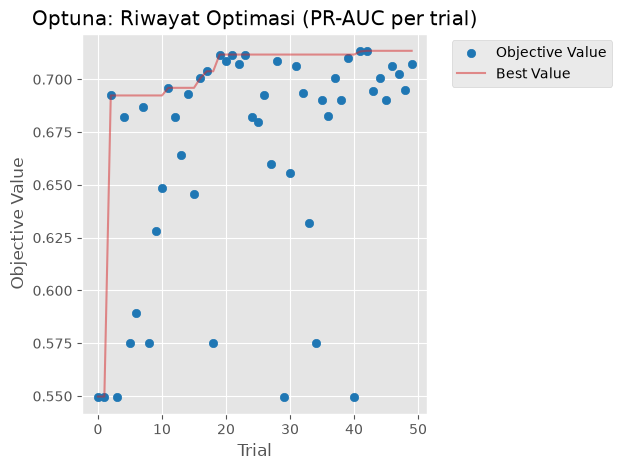

In [22]:
try:
    from optuna.visualization.matplotlib import plot_optimization_history
    ax = plot_optimization_history(study)
    ax.set_title("Optuna: Riwayat Optimasi (PR-AUC per trial)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Skip plot riwayat optimasi:", e)


### 7.1 Model Final: Decision Tree dengan Best Params

In [23]:
final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE, **study.best_params)),
])

t0 = time.perf_counter()
final_pipe.fit(X_train, y_train)
final_fit_time = time.perf_counter() - t0

t0 = time.perf_counter()
y_proba_test = final_pipe.predict_proba(X_test)[:, 1]
y_pred_test_default = final_pipe.predict(X_test)
final_predict_time = time.perf_counter() - t0

print(f"Fit time (full train)   : {final_fit_time:.4f} s")
print(f"Predict time (test)     : {final_predict_time:.4f} s")
print(f"Test F1 (thr=0.5)       : {f1_score(y_test, y_pred_test_default):.4f}")
print(f"Test PR-AUC (AP)        : {average_precision_score(y_test, y_proba_test):.4f}")
print(f"Test ROC-AUC            : {roc_auc_score(y_test, y_proba_test):.4f}")


Fit time (full train)   : 0.0706 s
Predict time (test)     : 0.0074 s
Test F1 (thr=0.5)       : 0.6572
Test PR-AUC (AP)        : 0.6864
Test ROC-AUC            : 0.9181


## 8. Threshold Tuning via PR Curve (Out-of-Fold, tanpa leakage)

Threshold optimal dicari dari **prediksi out-of-fold cross-validation di data TRAIN** (`cross_val_predict`), bukan langsung dari test set — supaya pemilihan threshold tidak *leak* informasi test set ke proses pemilihan model. Threshold yang ditemukan lalu diterapkan apa adanya ke test set untuk evaluasi akhir yang jujur.

In [24]:
oof_proba = cross_val_predict(
    final_pipe, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)

f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"Threshold optimal (OOF train, maksimalkan F1) : {optimal_threshold:.4f}")
print(f"  -> precision (OOF) @ threshold ini           : {precisions[best_idx]:.4f}")
print(f"  -> recall (OOF) @ threshold ini               : {recalls[best_idx]:.4f}")
print(f"  -> F1 (OOF) @ threshold ini                   : {f1_scores[best_idx]:.4f}")


Threshold optimal (OOF train, maksimalkan F1) : 0.3558
  -> precision (OOF) @ threshold ini           : 0.6538
  -> recall (OOF) @ threshold ini               : 0.6979
  -> F1 (OOF) @ threshold ini                   : 0.6751


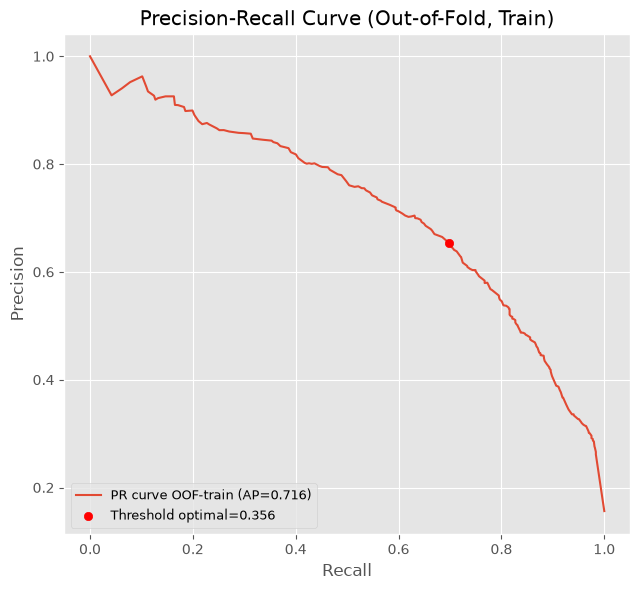

In [25]:
plt.figure(figsize=(6.5, 6))
plt.plot(recalls, precisions, label=f"PR curve OOF-train (AP={average_precision_score(y_train, oof_proba):.3f})")
plt.scatter(recalls[best_idx], precisions[best_idx], color="red", zorder=5,
            label=f"Threshold optimal={optimal_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Out-of-Fold, Train)")
plt.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()


## 9. Evaluasi Final di Test Set: Threshold Default (0.5) vs Threshold Optimal

In [26]:
y_pred_test_optimal = (y_proba_test >= optimal_threshold).astype(int)

final_comparison = pd.DataFrame([
    {
        "threshold": 0.5,
        "accuracy": accuracy_score(y_test, y_pred_test_default),
        "precision": precision_score(y_test, y_pred_test_default),
        "recall": recall_score(y_test, y_pred_test_default),
        "f1": f1_score(y_test, y_pred_test_default),
    },
    {
        "threshold": optimal_threshold,
        "accuracy": accuracy_score(y_test, y_pred_test_optimal),
        "precision": precision_score(y_test, y_pred_test_optimal),
        "recall": recall_score(y_test, y_pred_test_optimal),
        "f1": f1_score(y_test, y_pred_test_optimal),
    },
], index=["default (0.5)", "optimal (PR curve, OOF)"])

final_comparison


,threshold,accuracy,precision,recall,f1
default (0.5),0.500000,0.901270,0.719626,0.604712,0.657183
"optimal (PR curve, OOF)",0.355828,0.893896,0.654912,0.680628,0.667522


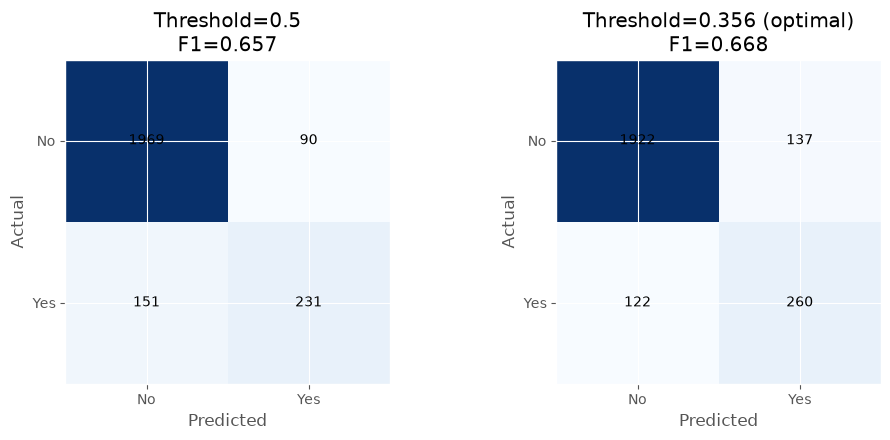

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

cm_default = confusion_matrix(y_test, y_pred_test_default)
axes[0].imshow(cm_default, cmap="Blues")
axes[0].set_title(f"Threshold=0.5\nF1={final_comparison.loc['default (0.5)', 'f1']:.3f}")

cm_optimal = confusion_matrix(y_test, y_pred_test_optimal)
axes[1].imshow(cm_optimal, cmap="Blues")
axes[1].set_title(f"Threshold={optimal_threshold:.3f} (optimal)\nF1={final_comparison.loc['optimal (PR curve, OOF)', 'f1']:.3f}")

for ax, cm in zip(axes, [cm_default, cm_optimal]):
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No", "Yes"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["No", "Yes"])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()


### 9.1 PR Curve & ROC Curve di Test Set (posisi kedua threshold ditandai)

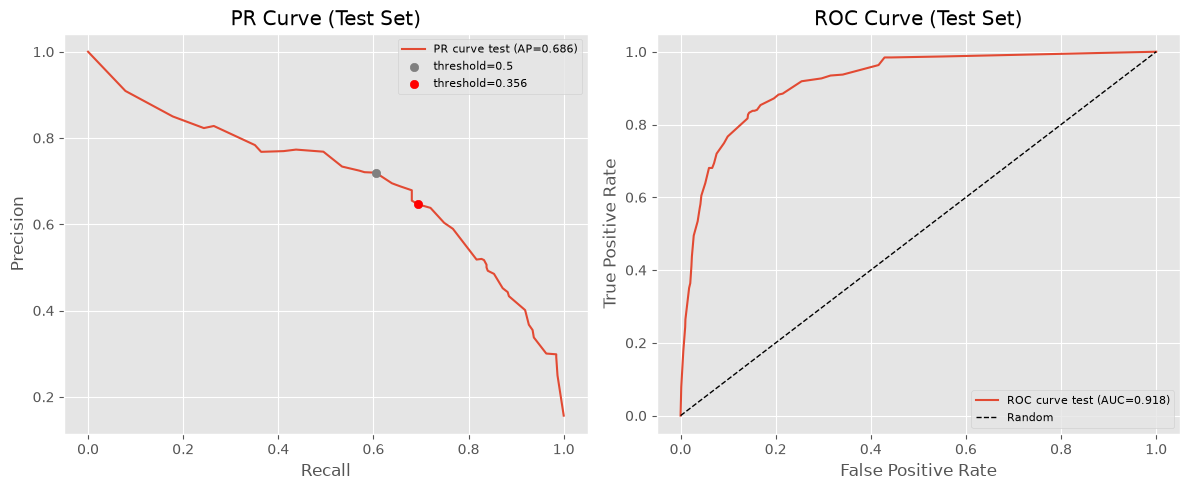

In [28]:
precisions_t, recalls_t, thresholds_t = precision_recall_curve(y_test, y_proba_test)
fpr_t, tpr_t, roc_thresholds_t = roc_curve(y_test, y_proba_test)

def closest_idx(arr, value):
    return int(np.argmin(np.abs(arr - value)))

idx_default = closest_idx(thresholds_t, 0.5)
idx_optimal = closest_idx(thresholds_t, optimal_threshold)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(recalls_t, precisions_t, label=f"PR curve test (AP={average_precision_score(y_test, y_proba_test):.3f})")
axes[0].scatter(recalls_t[idx_default], precisions_t[idx_default], color="gray", label="threshold=0.5", zorder=5)
axes[0].scatter(recalls_t[idx_optimal], precisions_t[idx_optimal], color="red", label=f"threshold={optimal_threshold:.3f}", zorder=5)
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("PR Curve (Test Set)")
axes[0].legend(fontsize=8)

axes[1].plot(fpr_t, tpr_t, label=f"ROC curve test (AUC={roc_auc_score(y_test, y_proba_test):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test Set)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 10. Simpan Model Final & Hasil

In [29]:
import joblib

out_dir = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."

model_path = os.path.join(out_dir, "final_decision_tree_model.joblib")
joblib.dump(final_pipe, model_path)

model_comparison_path = os.path.join(out_dir, "model_comparison_results.csv")
summary.to_csv(model_comparison_path, index=False)

final_result = {
    "model": "Decision Tree (Optuna-tuned, FINAL)",
    "best_params": study.best_params,
    "best_cv_pr_auc": study.best_value,
    "optimal_threshold": float(optimal_threshold),
    "fit_time_sec": final_fit_time,
    "predict_time_test_sec": final_predict_time,
    "test_metrics_threshold_0.5": final_comparison.loc["default (0.5)"].to_dict(),
    "test_metrics_threshold_optimal": final_comparison.loc["optimal (PR curve, OOF)"].to_dict(),
    "test_roc_auc": roc_auc_score(y_test, y_proba_test),
    "test_pr_auc": average_precision_score(y_test, y_proba_test),
}

metrics_path = os.path.join(out_dir, "final_decision_tree_metrics.json")
with open(metrics_path, "w") as f:
    _json.dump(final_result, f, indent=2, default=str)

final_comparison.to_csv(os.path.join(out_dir, "decision_tree_threshold_comparison.csv"))

print("Model final disimpan ke      :", model_path)
print("Perbandingan 7 model disimpan:", model_comparison_path)
print("Metrics final disimpan ke    :", metrics_path)


Model final disimpan ke      : ./final_decision_tree_model.joblib
Perbandingan 7 model disimpan: ./model_comparison_results.csv
Metrics final disimpan ke    : ./final_decision_tree_metrics.json


## Kesimpulan

Notebook ini membandingkan **7 model klasifikasi murah secara komputasi** (Logistic Regression, Decision Tree, Naive Bayes, KNN, Random Forest, XGBoost, LightGBM) di CPU, lalu memilih **Decision Tree sebagai model final** dengan alasan yang didokumentasikan di Bagian 6 (trade-off cost vs performa paling masuk akal — jauh lebih murah dari model berperforma terbaik, jauh lebih baik performanya dari model termurah lainnya).

Decision Tree kemudian di-tuning dengan **Optuna** (TPE sampler, 50 trials, objective = PR-AUC 5-fold CV), dan **threshold keputusannya dioptimalkan lewat PR curve** (out-of-fold, bukan dari test set — menghindari data leakage).

Lihat tabel `summary` (Bagian 5.3) untuk perbandingan lengkap 7 model, dan `final_comparison` (Bagian 9) untuk perbandingan performa Decision Tree pada threshold default (0.5) vs threshold optimal pada test set.

File output: `model_comparison_results.csv`, `final_decision_tree_model.joblib`, `final_decision_tree_metrics.json`, `decision_tree_threshold_comparison.csv`.